# Week 2 — Function 2: Bayesian Optimisation (2D)

In [8]:
# Cell 2: Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [9]:
# Cell 3: Load data and inspect
# Function 2: Noisy black-box ML model (log-likelihood scores), 2D input, Maximise

X = np.load('../data/function_2/initial_inputs.npy')
Y = np.load('../data/function_2/initial_outputs.npy')

print(f'Input  shape : {X.shape}   (n_samples x n_dimensions)')
print(f'Output shape : {Y.shape}  (n_samples,)')
print()

# Sort descending by Y value
X_list = list(X)
Y_list = list(Y)
pairs = sorted(zip(Y_list, X_list), reverse=True)
Y_sorted = [p[0] for p in pairs]
X_sorted = [p[1] for p in pairs]

print('=' * 62)
print('  All observations (sorted descending by Y)')
print('=' * 62)
for i, (y_val, x_val) in enumerate(zip(Y_sorted, X_sorted)):
    marker = '  <-- best' if i == 0 else ''
    print(f'  [{i+1:2d}]  X = [{x_val[0]:.8f}, {x_val[1]:.8f}]   Y = {y_val:+.6e}{marker}')
print('=' * 62)

best_Y = Y_sorted[0]
best_X = np.array(X_sorted[0])
print(f'\n  Best Y*  = {best_Y:.6e}')
print(f'  Best X*  = [{best_X[0]:.8f}, {best_X[1]:.8f}]')

Input  shape : (10, 2)   (n_samples x n_dimensions)
Output shape : (10,)  (n_samples,)

  All observations (sorted descending by Y)
  [ 1]  X = [0.70263656, 0.92656420]   Y = +6.112052e-01  <-- best
  [ 2]  X = [0.66579958, 0.12396913]   Y = +5.389961e-01
  [ 3]  X = [0.87779099, 0.77862750]   Y = +4.205862e-01
  [ 4]  X = [0.84527543, 0.71112027]   Y = +2.939929e-01
  [ 5]  X = [0.43816606, 0.68501826]   Y = +2.446193e-01
  [ 6]  X = [0.45464714, 0.29045518]   Y = +2.149645e-01
  [ 7]  X = [0.34174959, 0.02869772]   Y = +3.874902e-02
  [ 8]  X = [0.57771284, 0.77197318]   Y = +2.310555e-02
  [ 9]  X = [0.33864816, 0.21386725]   Y = -1.385762e-02
  [10]  X = [0.14269907, 0.34900513]   Y = -6.562362e-02

  Best Y*  = 6.112052e-01
  Best X*  = [0.70263656, 0.92656420]


In [10]:
# Cell 4: Fit GP with log-transformed Y

# Log-transform to handle extreme scale differences across observations
Y_fit = np.log(np.abs(Y) + 1e-300)

# Fixed RBF kernel (course style — no ConstantKernel, no optimisation)
kernel = RBF(length_scale=0.1, length_scale_bounds='fixed')
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10)
gp.fit(X, Y_fit)

print('=' * 62)
print('  GP Fitting Results')
print('=' * 62)
print(f'  Kernel                   : {gp.kernel_}')
print(f'  Log-marginal-likelihood  : {gp.log_marginal_likelihood_value_:.4f}')
print()

# Sanity check: predict at best known point
pred_mean, pred_std = gp.predict(best_X.reshape(1, -1), return_std=True)
actual_log = np.log(np.abs(best_Y) + 1e-300)
print('  Sanity check at best known X*:')
print(f'    X*                     = [{best_X[0]:.6f}, {best_X[1]:.6f}]')
print(f'    GP predicted mean      = {pred_mean[0]:.4f}  (log-space)')
print(f'    Actual log(|Y*|)       = {actual_log:.4f}  (log-space)')
print(f'    GP predicted std       = {pred_std[0]:.8f}')
print('=' * 62)

  GP Fitting Results
  Kernel                   : RBF(length_scale=0.1)
  Log-marginal-likelihood  : -32.1144

  Sanity check at best known X*:
    X*                     = [0.702637, 0.926564]
    GP predicted mean      = -0.4923  (log-space)
    Actual log(|Y*|)       = -0.4923  (log-space)
    GP predicted std       = 0.00001000


In [11]:
# Cell 5: UCB acquisition over 50x50 grid

# Build 50x50 meshgrid over [0, 1]^2
x1 = np.linspace(0, 1, 50)
x2 = np.linspace(0, 1, 50)
XX1, XX2 = np.meshgrid(x1, x2)
X_grid = np.column_stack([XX1.ravel(), XX2.ravel()])  # shape (2500, 2)

# GP predictions across the full grid
post_mean, post_std = gp.predict(X_grid, return_std=True)

# UCB acquisition: mean + beta * std
beta = 2.5  #Higher beta = more exploration at early stage (Week 1, sparse data)
acquisition = post_mean + beta * post_std  # shape (2500,)

# Next query = grid point with highest UCB
best_idx = np.argmax(acquisition)
next_x   = X_grid[best_idx]
next_acq = acquisition[best_idx]

# Portal submission string
portal_string = f'{next_x[0]:.6f}-{next_x[1]:.6f}'

print('=' * 62)
print('  UCB Acquisition  (beta = 2.5, 50x50 grid)')
print('=' * 62)
print(f'  Grid size            : {len(X_grid)} points (50x50)')
print(f'  Max UCB value        : {next_acq:.4f}')
print(f'  Next query point     : [{next_x[0]:.6f}, {next_x[1]:.6f}]')
print()
print('  Portal submission string:')
print(f'  >>> {portal_string} <<<')
print('=' * 62)

  UCB Acquisition  (beta = 2.5, 50x50 grid)
  Grid size            : 2500 points (50x50)
  Max UCB value        : 2.5000
  Next query point     : [0.000000, 1.000000]

  Portal submission string:
  >>> 0.000000-1.000000 <<<


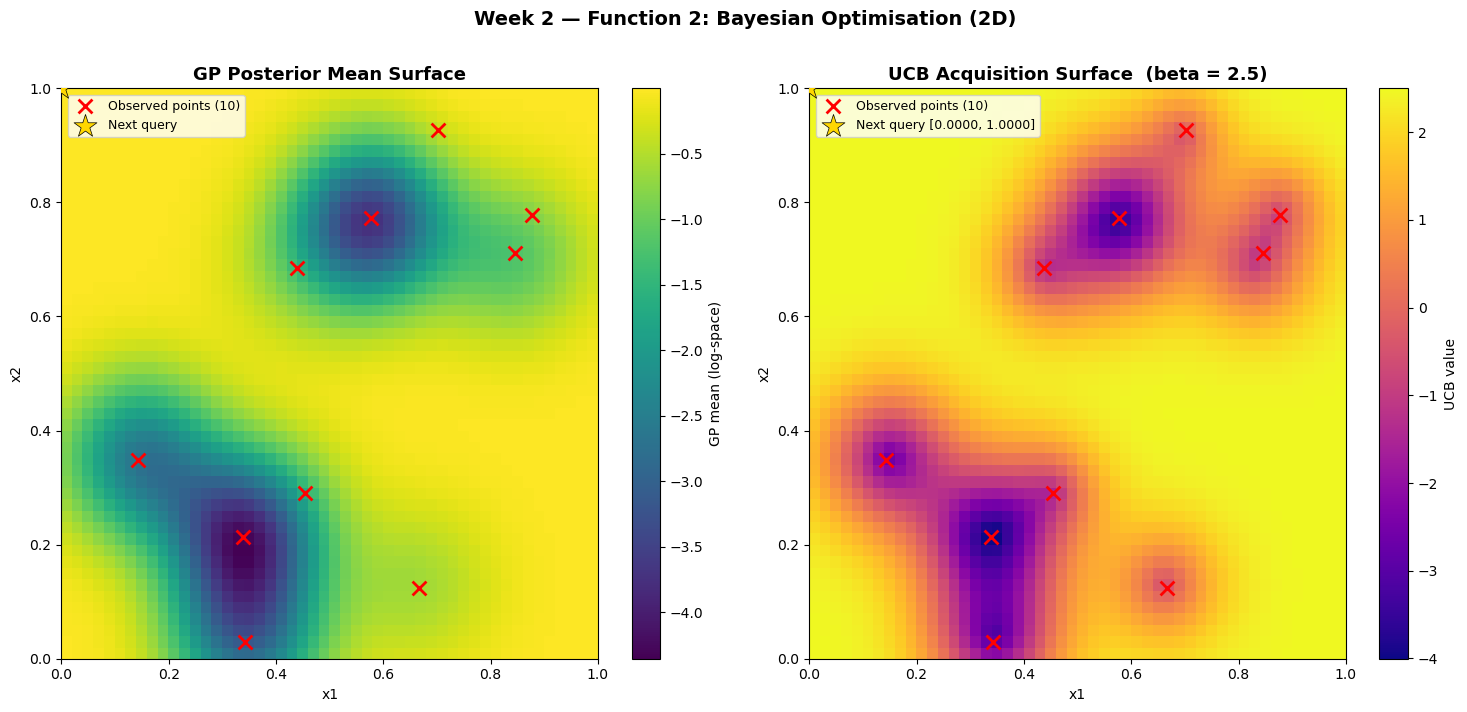

In [12]:
# Cell 6: Visualisation — GP mean surface and UCB surface

# Reshape flat predictions to (50, 50) for imshow
mean_surface = post_mean.reshape(50, 50)
ucb_surface  = acquisition.reshape(50, 50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# ── Left: GP posterior mean ──────────────────────────────────────────────────
im1 = ax1.imshow(
    mean_surface,
    origin='lower',
    extent=[0, 1, 0, 1],
    aspect='auto',
    cmap='viridis'
)
plt.colorbar(im1, ax=ax1, label='GP mean (log-space)')
ax1.scatter(X[:, 0], X[:, 1], c='r', marker='x', s=100, linewidths=2,
            label='Observed points (10)', zorder=5)
ax1.scatter(next_x[0], next_x[1], c='gold', marker='*', s=300, zorder=6,
            edgecolors='black', linewidths=0.5, label='Next query')
ax1.set_title('GP Posterior Mean Surface', fontsize=13, fontweight='bold')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.legend(loc='upper left', fontsize=9)

# ── Right: UCB acquisition surface ──────────────────────────────────────────
im2 = ax2.imshow(
    ucb_surface,
    origin='lower',
    extent=[0, 1, 0, 1],
    aspect='auto',
    cmap='plasma'
)
plt.colorbar(im2, ax=ax2, label='UCB value')
ax2.scatter(X[:, 0], X[:, 1], c='r', marker='x', s=100, linewidths=2,
            label='Observed points (10)', zorder=5)
ax2.scatter(next_x[0], next_x[1], c='gold', marker='*', s=300, zorder=6,
            edgecolors='black', linewidths=0.5,
            label=f'Next query [{next_x[0]:.4f}, {next_x[1]:.4f}]')
ax2.set_title('UCB Acquisition Surface  (beta = 2.5)', fontsize=13, fontweight='bold')
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.legend(loc='upper left', fontsize=9)

plt.suptitle('Week 2 — Function 2: Bayesian Optimisation (2D)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# Cell 7: Summary

print('=' * 62)
print('  SUMMARY — Bayesian Optimisation Results')
print('=' * 62)
print(f'  Function             : 2D Noisy Black-Box ML Model (log-likelihood)')
print(f'  Objective            : Maximise')
print(f'  Kernel               : RBF(length_scale=0.1, fixed)')
print(f'  Acquisition function : UCB  (beta = 2.5)')
print(f'  Y transform          : log(|Y| + 1e-300)')
print(f'  Grid search          : 50x50 meshgrid (2,500 points)')
print()
print(f'  Current best X*      : [{best_X[0]:.6f}, {best_X[1]:.6f}]')
print(f'  Current best Y*      : {best_Y:.6e}')
print()
print(f'  Next query point     : [{next_x[0]:.6f}, {next_x[1]:.6f}]')
print()
print('  Portal submission string:')
print(f'  >>> {portal_string} <<<')
print('=' * 62)

  SUMMARY — Bayesian Optimisation Results
  Function             : 2D Noisy Black-Box ML Model (log-likelihood)
  Objective            : Maximise
  Kernel               : RBF(length_scale=0.1, fixed)
  Acquisition function : UCB  (beta = 2.5)
  Y transform          : log(|Y| + 1e-300)
  Grid search          : 50x50 meshgrid (2,500 points)

  Current best X*      : [0.702637, 0.926564]
  Current best Y*      : 6.112052e-01

  Next query point     : [0.000000, 1.000000]

  Portal submission string:
  >>> 0.000000-1.000000 <<<
